# Matrix Factorisation with Gradient Descent

This notebook explains how **gradient descent** (slide 43 of **Recommender systems.pptx**) is used in **matrix factorisation** (slide 40).

- **Matrix factorisation** predicts missing ratings by describing every user and every item with a few numbers, called features. The features of all users form a matrix called $U$ (one row per user), and the features of all items form a matrix called $V$ (one column per item).
- **Gradient descent** finds the lowest point of a function by taking many small steps downhill. Here it is used to find good values for $U$ and $V$, namely values for which the predicted ratings are as close as possible to the ratings we know.

**Example.** On slide 40, user u3 has not rated item i2. From the learned $U$ and $V$, the model predicts that u3 would give i2 about 1.69 stars.

We use the rating table of slide 40 (and **UV-decomposition.xlsx**): 5 users and 5 items. For examples worked out completely by hand we also use an even smaller table with 2 users and 3 items.

**Contents**

- Notation
- 1\. Matrix factorisation (slide 40)
    - 1.1 Introduction
    - 1.2 Matrix factorisation
        - 1.2.1 The model
        - 1.2.2 The error function
- 2\. Gradient descent (slides 43 to 48)
    - 2.1 Introduction
    - 2.2 Gradient descent
    - 2.3 Gradient descent for matrix factorisation
        - 2.3.1 Introduction
        - 2.3.2 From two variables to all entries of U and V
        - 2.3.3 The partial derivatives of the error function
        - 2.3.4 The update step
        - 2.3.5 Case study: the rating table of slide 40
            - 2.3.5.1 The first steps by hand
            - 2.3.5.2 Only two numbers can change: the picture of slides 43 and 44
            - 2.3.5.3 All numbers at once
    - 2.4 Choosing the learning rate
    - 2.5 Remarks
        - 2.5.1 Introduction
        - 2.5.2 Why the start must be random
        - 2.5.3 Many equally good answers
        - 2.5.4 The error surface is not a simple bowl
        - 2.5.5 Overfitting
    - 2.6 Variants used in practice
        - 2.6.1 Introduction
        - 2.6.2 Stochastic gradient descent
        - 2.6.3 Regularisation
- 3\. Summary

The next cell loads the libraries used in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

np.set_printoptions(precision=2, suppress=True)

# Plot style: recessive axes and grid, thin marks
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "grid.linewidth": 0.8,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED = "#0b0b0b", "#52514e"

---

## Notation

All symbols of this notebook are collected here. Each one is also mentioned again in the text, right before it is first used.

| Symbol | Meaning | Short example |
|---|---|---|
| $m,\ n$ | number of users and number of items | $m = n = 5$ on slide 40 |
| $i,\ j$ | number of a user ($i = 1, \dots, m$) and of an item ($j = 1, \dots, n$) | $i = 3$ is the third user |
| $R,\ r_{ij}$ | the rating table (the utility matrix of the slides), and the rating of user $i$ for item $j$ | $r_{11} = 5$ on slide 40 |
| $K$ | number of features per user and per item (**feature_dimension** in **assignment.py**) | $K = 2$ on slide 40 |
| $d,\ d'$ | number of a feature, $d = 1, \dots, K$; $d'$ is a second feature number, used as the counter of a sum | d1 and d2 on slide 40 |
| $U,\ u_i,\ u_{id}$ | the user matrix ($m \times K$), row $i$ of it (the feature vector of user $i$), and feature $d$ of user $i$ | $u_1 = (2, 1.8)$ on slide 40 |
| $V,\ v_j,\ v_{dj}$ | the item matrix ($K \times n$), column $j$ of it (the feature vector of item $j$), and feature $d$ of item $j$ | $v_1 = (1.1, 0.8)$ on slide 40 |
| u1, ..., u5 and i1, ..., i5 | names of the users and items on slide 40, written in plain text | u1 is the name of user 1, $u_1$ is its feature vector |
| $\hat r_{ij},\ \hat R$ | the predicted rating (the hat means "predicted"), and the table of all predictions | $\hat r_{11} = 3.64$ on slide 40 |
| $e_{ij},\ E$ | the error of one known rating (real minus predicted), and the table of all errors (0 where the rating is missing) | $e_{11} = 5 - 3.64 = 1.36$ |
| $\Omega,\ \lvert\Omega\rvert$ | the list of all pairs $(i, j)$ whose rating is known (Omega is a Greek letter), and how many pairs there are | $\lvert\Omega\rvert = 23$ on slide 40 |
| $M,\ M_{ij}$ | the "mask": a table of the same size as $R$, with $M_{ij} = 1$ where the rating is known and 0 where it is missing (capital $M_{ij}$, because $m$ is the number of users) | row 3 of $M$ is $(1, 0, 1, 1, 1)$ on slide 40 |
| $\odot$ | multiply two tables of the same size entry by entry | $(1, 0) \odot (5, 3) = (5, 0)$ |
| $f(U, V)$ | the error function: one number that says how wrong the model is on the known ratings | 75 at the all-ones start of slide 40 |
| SSE (Sum of Squared Errors), MSE (Mean Squared Error), RMSE (Root Mean Squared Error) | $f$ itself; the average $f / \lvert\Omega\rvert$; and its square root, which is on the same scale as the ratings | 75; $75 / 23 = 3.26$; $\sqrt{3.26} = 1.81$ |
| $[a\ ;\ b]$ | a vector with the two numbers $a$ and $b$ (the way slide 43 writes it) | $[2\ ;\ 4]$ |
| $x,\ y,\ (x_0, y_0)$ | the two variables of slide 43, and the current point | $(x_0, y_0) = (1, 2)$ |
| $\eta$ | learning rate (the Greek letter eta): how big each step is (**learning_rate** in **assignment.py**) | $\eta = 0.01$ |
| $\leftarrow$ | "replace by": the variable on the left gets the value on the right | $x \leftarrow x + 1$ increases $x$ by 1 |
| $t$ | number of the step (iteration) of gradient descent; $t = 0$ is the start | $t = 3$ is the third step |
| $w_1,\ w_2,\ \Delta w$ | the two variables in the picture of slide 44, and how much they change in one step | |
| $\nabla_U f,\ \nabla_V f$ | the partial derivatives of $f$ for all entries of $U$ (a table shaped like $U$) and of $V$ (shaped like $V$) | entry $(1, 1)$ of $\nabla_U f$ is $\partial f / \partial u_{11}$ |
| $h$ | a tiny change of one number, used to test derivatives numerically | $h = 0.000001$ |
| $A,\ A^{-1}$ | any $K \times K$ matrix that can be undone, and the matrix that undoes it (its inverse) | "multiply by 2" is undone by "multiply by 0.5" |
| $\lVert u \rVert^2$ | squared length of a vector: the sum of its squared entries | $\lVert (2, 1.8) \rVert^2 = 4 + 3.24 = 7.24$ |
| $\lambda,\ f_\lambda$ | regularisation strength (the Greek letter lambda): how strongly large numbers are punished (**regularization** in **assignment.py**), and the error function with this punishment added | $\lambda = 0.02$ |

Well-known mathematical notation is used without further explanation: $\sum$ (sum), $\in$ (is in), $^\top$ (transpose), $a \times b$ (a table with $a$ rows and $b$ columns), $\partial f / \partial x$ (partial derivative), $\nabla f$ (gradient, the vector of all partial derivatives) and $\sqrt{\ }$ (square root).

---

## 1. Matrix factorisation (slide 40)

### 1.1 Introduction

Matrix factorisation fills in the missing entries of the rating table $R$ (the utility matrix), which has $m$ users as rows and $n$ items as columns; $r_{ij}$ is the rating of user $i$ for item $j$. Every user $i$ gets a feature vector $u_i$ and every item $j$ a feature vector $v_j$, both with $K$ numbers. A rating is predicted by the dot product of the two vectors, and all predictions together form the matrix product $UV$. The features are chosen so that the squared errors on the known ratings are small. Section 1.2.1 gives the model and section 1.2.2 the error function.

**Example.** On slide 40, $K = 2$, user u1 has the features (2, 1.8) and item i1 has the features (1.1, 0.8). The predicted rating is $2 \cdot 1.1 + 1.8 \cdot 0.8 = 3.64$, while the real rating is 5, so the prediction is 1.36 stars too low.

### 1.2 Matrix factorisation

#### 1.2.1 The model

**The subject.** The rating table $R$ of slide 40, with $m = 5$ users (rows) and $n = 5$ items (columns); "-" marks a missing rating:

| | i1 | i2 | i3 | i4 | i5 |
|---|---|---|---|---|---|
| u1 | 5 | 2 | 4 | 4 | 3 |
| u2 | 3 | 1 | 2 | 4 | 1 |
| u3 | 2 | - | 3 | 1 | 4 |
| u4 | 2 | 5 | 4 | 3 | 5 |
| u5 | 4 | 4 | 5 | 4 | - |

**The features.** Every user and every item is described by the same small number $K$ of features:

- user $i$ gets its feature vector $u_i$, with entries $u_{id}$ (feature $d$ of user $i$, $d = 1, \dots, K$),
- item $j$ gets its feature vector $v_j$, with entries $v_{dj}$ (feature $d$ of item $j$).

The features are not given in advance, they are learned from the ratings. Afterwards they often have a meaning, for example on slide 40 d1 = "prefers romantic comedies vs action" and d2 = "tendency toward niche indie vs blockbuster mainstream".

**The prediction.** A hat marks a predicted value: $\hat r_{ij}$ is the predicted rating of user $i$ for item $j$. It is the dot product of the two feature vectors (the slide says "rating = sum(user vector x item vector)"):

$$\hat r_{ij} = u_i^\top v_j = \sum_{d=1}^{K} u_{id}\, v_{dj}.$$

In words: the prediction is high when the user's features are large where the item's features are large, so when user and item "match".

**All predictions at once.** The user vectors are the rows of the matrix $U$ ($m \times K$) and the item vectors are the columns of the matrix $V$ ($K \times n$). Entry $(i, j)$ of the matrix product $UV$ is then exactly $\hat r_{ij}$, so the table of all predictions $\hat R$ is

$$\hat R = U V .$$

Note: in **assignment.py** the item matrix is stored the other way round (**item_matrix** has $n$ rows and $K$ columns), so there the product is written **np.dot(user_matrix, item_matrix.T)**. The idea is the same.

##### -##-Example:-##-

**The subject.** The rating table above with $K = 2$ and the features of slide 40: $u_1 = (u_{11}, u_{12}) = (2, 1.8)$, $u_2 = (1.3, 1.2)$, $v_1 = (v_{11}, v_{21}) = (1.1, 0.8)$ and $v_2 = (0.7, 0.9)$.

- **One prediction (the loop over the features).** For $d = 1$ the term is $u_{11} v_{11} = 2 \cdot 1.1 = 2.2$, for $d = 2$ it is $u_{12} v_{21} = 1.8 \cdot 0.8 = 1.44$, so $\hat r_{11} = 2.2 + 1.44 = 3.64$.
- **More predictions (the loop over users and items).** In the same way $\hat r_{12} = 2 \cdot 0.7 + 1.8 \cdot 0.9 = 3.02$, $\hat r_{21} = 1.3 \cdot 1.1 + 1.2 \cdot 0.8 = 2.39$ and $\hat r_{22} = 1.3 \cdot 0.7 + 1.2 \cdot 0.9 = 1.99$. These are the four top-left entries of the U*V table of slide 40.

The code stores the rating table and the matrices $U$ and $V$ of slide 40 and computes all predictions $UV$ at once:

In [2]:
# Utility matrix of slide 40 (rows: users u1..u5, columns: items i1..i5)
R = np.array([
    [5, 2,      4, 4, 3],
    [3, 1,      2, 4, 1],
    [2, np.nan, 3, 1, 4],
    [2, 5,      4, 3, 5],
    [4, 4,      5, 4, np.nan],
])
mask = ~np.isnan(R)                 # True where a rating is known
R_filled = np.where(mask, R, 0.0)   # missing ratings replaced by 0 (they are masked out anyway)

# Feature matrices shown on slide 40 (sheet "Final" of UV-decomposition.xlsx)
U_slide = np.array([[2.0, 1.8],
                    [1.3, 1.2],
                    [1.0, 1.1],
                    [1.4, 2.3],
                    [3.0, 0.5]])                   # users x features
V_slide = np.array([[1.1, 0.7, 1.3, 1.0, 0.4],
                    [0.8, 0.9, 0.8, 0.9, 1.5]])    # features x items

print("U*V =\n", U_slide @ V_slide)
print("\nNumber of known ratings |Omega| =", mask.sum())

U*V =
 [[3.64 3.02 4.04 3.62 3.5 ]
 [2.39 1.99 2.65 2.38 2.32]
 [1.98 1.69 2.18 1.99 2.05]
 [3.38 3.05 3.66 3.47 4.01]
 [3.7  2.55 4.3  3.45 1.95]]

Number of known ratings |Omega| = 23


The product gives the U*V table of slide 40; the top-left entries are the ones from the example. The two ratings that are missing in the rating table, (u3, i2) and (u5, i5), are the entries circled in red. The values **1.69** and **1.95** are the model's guesses for ratings that nobody has given yet. Making these guesses is the whole point of the method.

#### 1.2.2 The error function

**The subject.** The known ratings of $R$ and the predictions $\hat r_{ij}$ of section 1.2.1. We need one number that says how wrong the model is on the known ratings; the last line of slide 40 says: find the feature values that make this number as small as possible.

**The error of one rating.** For every known rating, the error $e_{ij}$ is the real rating minus the predicted rating:

$$e_{ij} = r_{ij} - u_i^\top v_j .$$

**The error function.** Let $\Omega$ (the Greek letter Omega) be the list of all pairs $(i, j)$ whose rating is known, and $\lvert\Omega\rvert$ the number of these pairs. We square each error, so that errors that are too high and too low both count and big errors count a lot, and add everything up. This gives the error function $f$ of slides 40 and 41:

$$f(U, V) = \sum_{(i,j)\in\Omega} \left(r_{ij} - u_i^\top v_j\right)^2 = \sum_{(i,j)\in\Omega} e_{ij}^2 .$$

**SSE, MSE and RMSE.** $f$ is the SSE (Sum of Squared Errors). The slide speaks of the MSE (Mean Squared Error), the average

$$\text{MSE} = \frac{f}{\lvert\Omega\rvert}.$$

Dividing by a fixed number does not change where the lowest point is, so both give the same $U$ and $V$. (It only makes the steps of gradient descent shorter, and a larger learning rate can make up for that.) We use the SSE, which is also what the "MSE" cell of the spreadsheet computes. To get a number on the same scale as the ratings, we also report the RMSE (Root Mean Squared Error) from slide 37, roughly the size of a typical error in stars:

$$\text{RMSE} = \sqrt{\frac{f}{\lvert\Omega\rvert}} .$$

**All errors at once.** In the code, all errors are computed at once as a table $E$. The mask $M$ is a table of the same size as $R$ that marks the known ratings (we write its entries with a capital $M_{ij}$, because $m$ is already the number of users):

$$M_{ij} = \begin{cases} 1 & \text{if } (i, j) \in \Omega, \\ 0 & \text{otherwise.} \end{cases}$$

With $\odot$ for the entry-by-entry product of two tables,

$$E = M \odot (R - UV), \qquad \text{that is,} \quad e_{ij} = M_{ij} \cdot \left(r_{ij} - \hat r_{ij}\right),$$

so missing ratings get error 0 and do not count. (In the code, the missing entries of $R$ are first filled with 0, since they are masked out anyway.)

**Remarks.**

- **Only known ratings are counted.** The spreadsheet does the same with **IF(ISBLANK(...), 0, ...)**. If a missing rating were counted as 0, the model would learn that users hate every item they have not rated.
- **f depends on every entry of U and V.** These entries are the unknowns we want to find: $(m + n) \cdot K$ numbers. For the Netflix data with 100 features this is about 50 million numbers (slides 41 and 46).

##### -##-Example:-##-

**The subject.** The rating table of slide 40, where $\lvert\Omega\rvert = 23$ and there are $(5 + 5) \cdot 2 = 20$ unknowns.

- **One error.** With the slide 40 features, $e_{11} = r_{11} - \hat r_{11} = 5 - 3.64 = 1.36$.
- **The error function (the loop over the known ratings).** In the spreadsheet's "Start" sheet all features are 1, so every prediction is $1 \cdot 1 + 1 \cdot 1 = 2$. Inner loop, the ratings of user u1: the ratings 5, 2, 4, 4, 3 give the errors 3, 0, 2, 2, 1 and the squares $9 + 0 + 4 + 4 + 1 = 18$. Outer loop, all users: users u1 to u5 give 18, 7, 6, 23 and 21, so $f = 75$.
- **MSE and RMSE.** $\text{MSE} = 75 / 23 = 3.26$ and $\text{RMSE} = \sqrt{3.26} = 1.81$.
- **The mask.** Row 3 of $M$ is $(1, 0, 1, 1, 1)$, because rating (u3, i2) is missing: $M_{32} = 0$. So the error in row 3, column 2 of $E$ is $0 \cdot (\dots) = 0$.

The code computes the SSE and RMSE for the all-ones start and for the features of slide 40:

In [3]:
def errors(U, V):
    # E = M * (R - UV): error of every known rating, 0 for the missing ones
    return np.where(mask, R_filled - U @ V, 0.0)

def sse(U, V):
    # f(U, V): sum of squared errors over the known ratings
    return np.sum(errors(U, V) ** 2)

def rmse(U, V):
    return np.sqrt(sse(U, V) / mask.sum())

U_start, V_start = np.ones((5, 2)), np.ones((2, 5))   # sheet "Start" of the spreadsheet

print(f"Start (all ones): SSE = {sse(U_start, V_start):6.2f}, RMSE = {rmse(U_start, V_start):.3f}")
print(f"Slide 40 values:  SSE = {sse(U_slide, V_slide):6.2f}, RMSE = {rmse(U_slide, V_slide):.3f}")

Start (all ones): SSE =  75.00, RMSE = 1.806
Slide 40 values:  SSE =  24.89, RMSE = 1.040


The code confirms the example: the all-ones start gives SSE 75 and RMSE 1.81. The features of slide 40 lower the error to 24.89, but they were found by trying. Section 2 shows how gradient descent finds good values automatically, by always going downhill on $f$.

---

## 2. Gradient descent (slides 43 to 48)

### 2.1 Introduction

Gradient descent finds a minimum (lowest point) of a function $f$ by repeating one move: take a small step in the direction in which $f$ goes down the fastest. That direction is $-\nabla f$, minus the gradient (the vector of the partial derivatives $\partial f / \partial x$); slide 43 writes a vector with the numbers $a$ and $b$ as $[a\ ;\ b]$. The size of the steps is set by the learning rate $\eta$. Section 2.2 gives the algorithm of slide 43, section 2.3 applies it to the error function $f(U, V)$ of section 1.2.2, and sections 2.4 to 2.6 discuss the step size, some remarks and two variants used in practice.

**Example.** The function $x^2 + y^2$ is a bowl with its lowest point at $(0, 0)$. Standing at $(1, 2)$, where the value is 5, the fastest way down points in the direction $(-2, -4)$. A step of 0.1 times this direction leads to $(0.8, 1.6)$, where the value is only 3.2.

### 2.2 Gradient descent

**The subject.** A function $f(x, y)$ of two variables $x$ and $y$ that we want to make as small as possible.

**The algorithm (slide 43).** The learning rate $\eta$ is a small positive number, and $\leftarrow$ means "replace by" (the slide writes "="):

1. Start at any point $(x_0, y_0)$.
2. Find the direction in which $f$ goes down the fastest:
$$-\left[\frac{\partial f(x_0, y_0)}{\partial x}\ ;\ \frac{\partial f(x_0, y_0)}{\partial y}\right]$$
3. Take a small step in this direction:
$$(x_0, y_0) \leftarrow (x_0, y_0) - \eta \left[\frac{\partial f(x_0, y_0)}{\partial x}\ ;\ \frac{\partial f(x_0, y_0)}{\partial y}\right]$$
4. Repeat steps 2 and 3.

**The picture of slide 44.** Slide 44 shows one such step on the error surface of two variables $w_1$ and $w_2$: from the point $(w_1, w_2)$ to $(w_1 + \Delta w_1, w_2 + \Delta w_2)$, where $\Delta w = (\Delta w_1, \Delta w_2)$ is the step, $-\eta$ times the gradient. (Slide 44 calls the error function $E$. In this notebook $E$ is the table of errors from section 1.2.2, and the error function is always called $f$.)

#### -##-Example:-##-

**The subject.** The function

$$f(x, y) = x^2 + y^2, \qquad \text{with} \quad \frac{\partial f}{\partial x} = 2x, \quad \frac{\partial f}{\partial y} = 2y,$$

the start $(x_0, y_0) = (1, 2)$ and $\eta = 0.1$. We write $t$ for the number of the step ($t = 0$ is the start).

| step $t$ | gradient at the old point | new point $(x_0, y_0)$ | $f$ at the new point |
|---|---|---|---|
| 0 (start) | | $(1, 2)$ | 5 |
| 1 | $[2\ ;\ 4]$ | $(1, 2) - 0.1 \cdot (2, 4) = (0.8, 1.6)$ | 3.2 |
| 2 | $[1.6\ ;\ 3.2]$ | $(0.8, 1.6) - 0.1 \cdot (1.6, 3.2) = (0.64, 1.28)$ | 2.048 |
| 3 | $[1.28\ ;\ 2.56]$ | $(0.64, 1.28) - 0.1 \cdot (1.28, 2.56) = (0.512, 1.024)$ | 1.311 |

Every step moves the point 20 % closer to the lowest point $(0, 0)$, and $f$ keeps going down.

### 2.3 Gradient descent for matrix factorisation

#### 2.3.1 Introduction

The algorithm of section 2.2 is used unchanged on the error function $f(U, V)$ of section 1.2.2. The unknowns are now all entries of $U$ and $V$ instead of $x$ and $y$ (section 2.3.2), and their partial derivatives are needed (section 2.3.3). Section 2.3.4 puts everything into one update step, and section 2.3.5 runs the algorithm on the rating table of slide 40.

**Example.** On slide 40, from the all-ones start of the spreadsheet with $\eta = 0.01$, the first step moves $u_{11}$ from 1 to 1.16 and lowers the error from 75 to 46.47 (section 2.3.5.1).

#### 2.3.2 From two variables to all entries of U and V

In matrix factorisation the "point" of slide 43 is the list of **all** unknowns: the entries of $U$ and of $V$. On slide 40 these are 20 numbers, $u_{11}, u_{12}, \dots, u_{52}$ and $v_{11}, \dots, v_{25}$, where slide 43 has only $x$ and $y$. The algorithm stays the same, only the objects change:

| Slide 43 | Matrix factorisation (slide 40) |
|---|---|
| the variables $x, y$ | all entries $u_{id}$ of $U$ and $v_{dj}$ of $V$ (20 numbers) |
| the function $f(x, y)$ | $f(U, V)$, the SSE over the known ratings |
| any start point $(x_0, y_0)$ | random $U$ and $V$ (all ones in the spreadsheet) |
| $\partial f / \partial x,\ \partial f / \partial y$ | $\partial f / \partial u_{id}$ for every user and feature, and $\partial f / \partial v_{dj}$ for every feature and item |
| the step size $\eta$ | the learning rate (**learning_rate** in **assignment.py**) |
| repeat | a fixed number of steps (**n_steps**), or until $f$ stops going down |

#### 2.3.3 The partial derivatives of the error function

**The subject.** The error function of section 1.2.2,

$$f(U, V) = \sum_{(i,j)\in\Omega} \left(r_{ij} - u_i^\top v_j\right)^2, \qquad e_{ij} = r_{ij} - u_i^\top v_j .$$

**One term.** Take one unknown, $u_{id}$ (feature $d$ of user $i$). It only appears in the predictions for user $i$. To keep the counter of the sum apart from the fixed feature $d$, we call the counter $d'$:

$$\hat r_{ij} = \sum_{d'=1}^{K} u_{id'}\, v_{d'j}.$$

All other terms of $f$ do not contain $u_{id}$, so their derivative is 0. In a term that does contain $u_{id}$, only the part $-u_{id} v_{dj}$ of $e_{ij}$ depends on $u_{id}$, so by the chain rule

$$\frac{\partial}{\partial u_{id}} \left(r_{ij} - u_i^\top v_j\right)^2 = 2\, e_{ij} \cdot (-v_{dj}) = -2\, e_{ij}\, v_{dj} .$$

**All terms.** Adding this up over all items that user $i$ has rated (written $\sum_{j:\,(i,j)\in\Omega}$), and doing the same for $v_{dj}$ (a sum over all users $i$ who rated item $j$), gives:

$$\frac{\partial f}{\partial u_{id}} = -2 \sum_{j:\,(i,j)\in\Omega} e_{ij}\, v_{dj}, \qquad \frac{\partial f}{\partial v_{dj}} = -2 \sum_{i:\,(i,j)\in\Omega} e_{ij}\, u_{id}.$$

**What the formulas say in words.**

- Suppose the model predicts too low for user $i$ ($e_{ij} > 0$) on items that score high on feature $d$. Then the derivative is negative, and step 3 **increases** $u_{id}$, so the next predictions for these items go up. In short: a user's vector moves towards the vectors of the items it predicts too low, and away from the items it predicts too high. Slide 46 says the same: "nudge the user vector in the direction of the movie vector and nudge the movie vector in the direction of the user vector".
- Items that user $i$ has not rated have $e_{ij} = 0$ and add nothing. So, apart from the mask, missing ratings need no special treatment.

##### -##-Example:-##-

**The subject.** A small rating table with 2 users and 3 items, and $K = 1$ feature:

| | item 1 | item 2 | item 3 |
|---|---|---|---|
| user 1 | 5 | 3 | - |
| user 2 | 4 | - | 2 |

With a single feature, every user and every item has just one number, so we write $u_i = u_{i1}$ and $v_j = v_{1j}$. The known ratings are $\Omega = \{(1, 1), (1, 2), (2, 1), (2, 3)\}$, so the error function is

$$f(u, v) = (5 - u_1 v_1)^2 + (3 - u_1 v_2)^2 + (4 - u_2 v_1)^2 + (2 - u_2 v_3)^2 .$$

We start with all features equal to 1: $u = (1, 1)$ and $v = (1, 1, 1)$. Every prediction is 1, so the errors are $e_{11} = 4$, $e_{12} = 2$, $e_{21} = 3$, $e_{23} = 1$, and $f = 16 + 4 + 9 + 1 = 30$.

Each derivative is a loop (a running sum) over the ratings of one user or one item:

| derivative | ratings visited, term $e \cdot$ feature, running sum | result ($-2 \cdot$ sum) |
|---|---|---|
| $\partial f / \partial u_1$ | item 1: $4 \cdot 1 = 4$ (sum 4); item 2: $2 \cdot 1 = 2$ (sum 6); item 3: not rated, skipped | $-12$ |
| $\partial f / \partial u_2$ | item 1: $3 \cdot 1 = 3$ (sum 3); item 2: not rated, skipped; item 3: $1 \cdot 1 = 1$ (sum 4) | $-8$ |
| $\partial f / \partial v_1$ | user 1: $4 \cdot 1 = 4$ (sum 4); user 2: $3 \cdot 1 = 3$ (sum 7) | $-14$ |
| $\partial f / \partial v_2$ | user 1: $2 \cdot 1 = 2$ (sum 2); user 2: not rated, skipped | $-4$ |
| $\partial f / \partial v_3$ | user 1: not rated, skipped; user 2: $1 \cdot 1 = 1$ (sum 1) | $-2$ |

All derivatives are negative, so every feature should grow: all predictions (1) are below the real ratings.

##### A numerical test

Before the formulas are used, we test them numerically: change one entry by a tiny amount $h$ (here $h = 0.000001$) up and down, and divide the change of $f$ by $2h$:

$$\frac{\partial f}{\partial u_{id}} \approx \frac{f(\dots,\ u_{id} + h,\ \dots) - f(\dots,\ u_{id} - h,\ \dots)}{2h} .$$

This should give (almost) the same numbers as the formulas.

In [4]:
def gradients(U, V):
    # Partial derivatives of f with respect to every entry of U and V
    E = errors(U, V)
    grad_U = -2 * E @ V.T     # df/du_id = -2 * sum_j e_ij * v_dj
    grad_V = -2 * U.T @ E     # df/dv_dj = -2 * sum_i e_ij * u_id
    return grad_U, grad_V

def numerical_gradient(func, X, h=1e-6):
    # Numerical test: move one entry of X a tiny amount h up and down,
    # and measure how much func changes per unit of change
    grad = np.zeros_like(X)
    for idx in np.ndindex(X.shape):
        step = np.zeros_like(X)
        step[idx] = h
        grad[idx] = (func(X + step) - func(X - step)) / (2 * h)
    return grad

rng = np.random.default_rng(0)
U_test, V_test = rng.random((5, 2)), rng.random((2, 5))
grad_U, grad_V = gradients(U_test, V_test)
num_grad_U = numerical_gradient(lambda U: sse(U, V_test), U_test)
num_grad_V = numerical_gradient(lambda V: sse(U_test, V), V_test)

print(f"largest difference between formula and numerical test, U: {np.abs(grad_U - num_grad_U).max():.1e}")
print(f"largest difference between formula and numerical test, V: {np.abs(grad_V - num_grad_V).max():.1e}")

largest difference between formula and numerical test, U: 2.1e-08
largest difference between formula and numerical test, V: 1.8e-08


The formulas and the numerical test agree up to tiny rounding errors (about 0.00000002), so the formulas are correct.

#### 2.3.4 The update step

**The subject.** The error function $f(U, V)$ of section 1.2.2 and its partial derivatives from section 2.3.3.

**All derivatives at once.** We collect the partial derivatives in two tables with the same shape as $U$ and $V$: $\nabla_U f$ has $\partial f / \partial u_{id}$ in row $i$, column $d$, and $\nabla_V f$ has $\partial f / \partial v_{dj}$ in row $d$, column $j$. With the error table $E$ of section 1.2.2 (0 where a rating is missing), the sums of section 2.3.3 are exactly matrix products:

$$\nabla_U f = -2\, E\, V^\top \quad (m \times K), \qquad \nabla_V f = -2\, U^\top E \quad (K \times n).$$

**The update.** Step 3 of slide 43 then becomes

$$U \leftarrow U - \eta\, \nabla_U f = U + 2\eta\, E V^\top, \qquad V \leftarrow V - \eta\, \nabla_V f = V + 2\eta\, U^\top E .$$

Important: both derivatives are computed at the **same** current point $(U, V)$, just as slide 43 computes both partial derivatives at the same point $(x_0, y_0)$. So within one step, the new $U$ is not yet used to compute the derivative for $V$. Many implementations leave out the factor 2; that only means their $\eta$ is twice as large.

##### -##-Example:-##-

**The subject.** The 2 x 3 table of section 2.3.3 with its error function

$$f(u, v) = (5 - u_1 v_1)^2 + (3 - u_1 v_2)^2 + (4 - u_2 v_1)^2 + (2 - u_2 v_3)^2,$$

the start $u = (1, 1)$, $v = (1, 1, 1)$ (where $f = 30$), and $\eta = 0.05$. The algorithm has nested loops: the running sums inside each derivative (shown in section 2.3.3), the loop over all unknowns, and the outer loop over the steps. We continue from the inside out.

**Loop over all unknowns (step 1).** Each unknown moves by $-\eta$ times its derivative:

| unknown | old value | derivative | new value |
|---|---|---|---|
| $u_1$ | 1 | $-12$ | $1 - 0.05 \cdot (-12) = 1.6$ |
| $u_2$ | 1 | $-8$ | $1 - 0.05 \cdot (-8) = 1.4$ |
| $v_1$ | 1 | $-14$ | $1 - 0.05 \cdot (-14) = 1.7$ |
| $v_2$ | 1 | $-4$ | $1 - 0.05 \cdot (-4) = 1.2$ |
| $v_3$ | 1 | $-2$ | $1 - 0.05 \cdot (-2) = 1.1$ |

The new predictions are $1.6 \cdot 1.7 = 2.72$, $1.6 \cdot 1.2 = 1.92$, $1.4 \cdot 1.7 = 2.38$ and $1.4 \cdot 1.1 = 1.54$, so the errors are 2.28, 1.08, 1.62, 0.46 and $f = 5.198 + 1.166 + 2.624 + 0.212 = 9.20$.

**The same with the table formulas.** Here $E = \begin{pmatrix} 4 & 2 & 0 \\ 3 & 0 & 1 \end{pmatrix}$ and $V = (1, 1, 1)$, so $E V^\top = (4 + 2 + 0,\ 3 + 0 + 1) = (6, 4)$ and $\nabla_U f = -2 \cdot (6, 4) = (-12, -8)$, the same as the running sums.

**Outer loop over the steps.** Repeating the step (the code below does the arithmetic):

| step $t$ | $u_1$ | $u_2$ | $v_1$ | $v_2$ | $v_3$ | $f$ |
|---|---|---|---|---|---|---|
| 0 (start) | 1 | 1 | 1 | 1 | 1 | 30 |
| 1 | 1.6 | 1.4 | 1.7 | 1.2 | 1.1 | 9.2008 |
| 2 | 2.1172 | 1.7260 | 2.2916 | 1.3728 | 1.1644 | 0.0328 |
| 3 | 2.1640 | 1.7351 | 2.3307 | 1.3926 | 1.1627 | 0.0043 |

After three steps the four known ratings are matched almost exactly. The two missing ratings are now predicted as $u_1 v_3 = 2.164 \cdot 1.1627 = 2.52$ and $u_2 v_2 = 1.7351 \cdot 1.3926 = 2.42$.

In [5]:
# The 2 x 3 example table with K = 1: repeat the three steps computed by hand
R_toy = np.array([[5, 3, np.nan],
                  [4, np.nan, 2]])
mask_toy = ~np.isnan(R_toy)
R_toy_filled = np.where(mask_toy, R_toy, 0.0)
eta_toy = 0.05

def f_toy(u, v):
    # f(u, v): sum of squared errors over the four known ratings
    return np.sum(np.where(mask_toy, R_toy_filled - np.outer(u, v), 0.0) ** 2)

u_toy, v_toy = np.ones(2), np.ones(3)                  # start: all features equal to 1
print(f"step 0: u = {np.array2string(u_toy, precision=4)}, v = {np.array2string(v_toy, precision=4)}, f = {f_toy(u_toy, v_toy):.4f}")
for t in range(1, 4):                                   # outer loop: the steps
    E_toy = np.where(mask_toy, R_toy_filled - np.outer(u_toy, v_toy), 0.0)
    grad_u = -2 * E_toy @ v_toy                         # df/du_i = -2 * sum_j e_ij * v_j
    grad_v = -2 * E_toy.T @ u_toy                       # df/dv_j = -2 * sum_i e_ij * u_i
    u_toy, v_toy = u_toy - eta_toy * grad_u, v_toy - eta_toy * grad_v
    print(f"step {t}: u = {np.array2string(u_toy, precision=4)}, v = {np.array2string(v_toy, precision=4)}, f = {f_toy(u_toy, v_toy):.4f}")

step 0: u = [1. 1.], v = [1. 1. 1.], f = 30.0000
step 1: u = [1.6 1.4], v = [1.7 1.2 1.1], f = 9.2008
step 2: u = [2.1172 1.726 ], v = [2.2916 1.3728 1.1644], f = 0.0328
step 3: u = [2.164  1.7351], v = [2.3307 1.3926 1.1627], f = 0.0043


#### 2.3.5 Case study: the rating table of slide 40

**The subject.** The 5 x 5 rating table of slide 40 (section 1.2.1) with $K = 2$ features, so 20 unknowns, and its error function over the 23 known ratings,

$$f(U, V) = \sum_{(i,j)\in\Omega} \left(r_{ij} - u_i^\top v_j\right)^2 .$$

Section 2.3.5.1 carries out the first steps by hand, section 2.3.5.2 draws the picture of slides 43 and 44 with only two free numbers, and section 2.3.5.3 runs the algorithm on all 20 numbers.

##### 2.3.5.1 The first steps by hand

**The subject.** The error function above, starting from the sheet "Start" of the spreadsheet (all features equal to 1, so every prediction is 2 and $f = 75$), with $\eta = 0.01$.

###### -##-Example:-##-

We go from the innermost loop to the outermost.

**Running sums inside two derivatives.** User u1 has the ratings 5, 2, 4, 4, 3, so its errors are 3, 0, 2, 2, 1, and all $v_{1j} = 1$. Adding up $e_{1j} v_{1j}$ item by item gives the running sums 3, 3, 5, 7, 8. Item i1 has the ratings 5, 3, 2, 2, 4, so its errors are 3, 1, 0, 0, 2, and all $u_{i1} = 1$. Adding up $e_{i1} u_{i1}$ user by user gives 3, 4, 4, 4, 6. So

$$\frac{\partial f}{\partial u_{11}} = -2 \cdot 8 = -16, \qquad \frac{\partial f}{\partial v_{11}} = -2 \cdot 6 = -12 .$$

**Updating the unknowns (step 1).**

$$u_{11} \leftarrow 1 - 0.01 \cdot (-16) = 1.16, \qquad v_{11} \leftarrow 1 - 0.01 \cdot (-12) = 1.12 .$$

Both derivatives are negative, so both features grow: the model predicts 2 for every item, which is lower than (or equal to) every rating of user u1. With the table formulas: entry $(1, 1)$ of $E V^\top$ is row 1 of $E$ times row 1 of $V$, $3 + 0 + 2 + 2 + 1 = 8$, so $u_{11} = 1 + 2 \cdot 0.01 \cdot 8 = 1.16$, the same result. The code does this for all 20 unknowns.

**Steps 1 to 3 (the outer loop).**

| step $t$ | $\partial f / \partial u_{11}$ | $u_{11}$ | $v_{11}$ | SSE |
|---|---|---|---|---|
| 0 (start) | | 1 | 1 | 75 |
| 1 | $-16$ | 1.16 | 1.12 | 46.47 |
| 2 | $-11.45$ | 1.2745 | 1.2003 | 32.23 |
| 3 | $-6.78$ | 1.3423 | 1.2419 | 26.73 |

In [6]:
eta = 0.01
grad_U, grad_V = gradients(U_start, V_start)
print("Errors E at the start (0 for the missing ratings):\n", errors(U_start, V_start))
print("\ndf/dU:\n", grad_U)
print("\ndf/dV:\n", grad_V)

U_new = U_start - eta * grad_U    # step 3 of slide 43, for all parameters at once
V_new = V_start - eta * grad_V
print("\nU after one step:\n", U_new)
print("\nV after one step:\n", V_new)
print(f"\nSSE: {sse(U_start, V_start):.2f} -> {sse(U_new, V_new):.2f}")

# The outer loop of the algorithm: steps 1 to 3 from the same start
print("\nThe first three steps:")
U_t, V_t = U_start.copy(), V_start.copy()
for t in range(1, 4):
    grad_U, grad_V = gradients(U_t, V_t)
    U_t, V_t = U_t - eta * grad_U, V_t - eta * grad_V
    print(f"step {t}: u_11 = {U_t[0, 0]:.4f}, v_11 = {V_t[0, 0]:.4f}, SSE = {sse(U_t, V_t):.2f}")

Errors E at the start (0 for the missing ratings):
 [[ 3.  0.  2.  2.  1.]
 [ 1. -1.  0.  2. -1.]
 [ 0.  0.  1. -1.  2.]
 [ 0.  3.  2.  1.  3.]
 [ 2.  2.  3.  2.  0.]]

df/dU:
 [[-16. -16.]
 [ -2.  -2.]
 [ -4.  -4.]
 [-18. -18.]
 [-18. -18.]]

df/dV:
 [[-12.  -8. -16. -12. -10.]
 [-12.  -8. -16. -12. -10.]]

U after one step:
 [[1.16 1.16]
 [1.02 1.02]
 [1.04 1.04]
 [1.18 1.18]
 [1.18 1.18]]

V after one step:
 [[1.12 1.08 1.16 1.12 1.1 ]
 [1.12 1.08 1.16 1.12 1.1 ]]

SSE: 75.00 -> 46.47

The first three steps:
step 1: u_11 = 1.1600, v_11 = 1.1200, SSE = 46.47
step 2: u_11 = 1.2745, v_11 = 1.2003, SSE = 32.23
step 3: u_11 = 1.3423, v_11 = 1.2419, SSE = 26.73


The code shows the same numbers as the hand computation: $-16$ and $1.16$ for $u_{11}$, $-12$ and $1.12$ for $v_{11}$, and the SSE going from 75 to 46.47, 32.23 and 26.73. Notice that features d1 and d2 got exactly the **same** updates (both columns of $U$ are equal). Section 2.5.2 explains why this matters.

##### 2.3.5.2 Only two numbers can change: the picture of slides 43 and 44

**The subject.** We keep all unknowns fixed except the two features of user u1, $x = u_{11}$ and $y = u_{12}$, and keep $V$ at the slide 40 values. (Slide 42 uses the same trick with a single variable.) Only the five ratings of user u1 then depend on $(x, y)$, so, leaving out the fixed terms, the error becomes a function of two variables, exactly like $f(x, y)$ on slide 43. Here $r_{1j}$ is the rating of user u1 for item $j$, $v_{1j}$ and $v_{2j}$ are features d1 and d2 of item $j$ (rows 1 and 2 of $V$), and $e_{1j} = r_{1j} - x\, v_{1j} - y\, v_{2j}$ is the error of user u1 on item $j$:

$$f(x, y) = \sum_{j=1}^{5} \left(r_{1j} - x\, v_{1j} - y\, v_{2j}\right)^2,
\qquad
\frac{\partial f}{\partial x} = -2 \sum_{j} e_{1j} v_{1j},
\qquad
\frac{\partial f}{\partial y} = -2 \sum_{j} e_{1j} v_{2j}.$$

###### -##-Example:-##-

**The subject.** The function $f(x, y)$ above, the start $(x_0, y_0) = (-1, 3)$, and $\eta = 0.05$. At the start the predictions for the five items are $-1 \cdot v_{1j} + 3 \cdot v_{2j} = 1.3,\ 2.0,\ 1.1,\ 1.7,\ 4.1$, so the errors are $3.7,\ 0,\ 2.9,\ 2.3,\ -1.1$ and $f(-1, 3) = 28.6$.

| step $t$ | gradient at the old point | new point $(x, y)$ | $f$ at the new point |
|---|---|---|---|
| 0 (start) | | $(-1, 3)$ | 28.6 |
| 1 | $[-19.4\ ;\ -11.4]$ | $(-1 + 0.05 \cdot 19.4,\ 3 + 0.05 \cdot 11.4) = (-0.03,\ 3.57)$ | 13.72 |
| 2 | $[-5.96\ ;\ 2.33]$ | $(0.268,\ 3.454)$ | 11.87 |
| 3 | $[-4.19\ ;\ 3.54]$ | $(0.477,\ 3.277)$ | 10.42 |

The code runs 40 steps and draws them:

In [7]:
# Freeze V (slide 40 values) and all users except u1; free variables: x = u_11, y = u_12
r1 = R[0]                            # ratings of user u1
v_d1, v_d2 = V_slide[0], V_slide[1]  # rows of V: feature d1 and feature d2 of every item

def f_xy(x, y):
    # Part of f that depends on (x, y): the five ratings of user u1
    return sum((r1[j] - x * v_d1[j] - y * v_d2[j]) ** 2 for j in range(5))

def grad_xy(x, y):
    e = r1 - (x * v_d1 + y * v_d2)                         # errors of user u1
    return -2 * np.sum(e * v_d1), -2 * np.sum(e * v_d2)    # [df/dx ; df/dy]

x, y = -1.0, 3.0                        # step 1: arbitrary starting point (x0, y0)
eta_xy = 0.05
path = [(x, y)]
for _ in range(40):
    gx, gy = grad_xy(x, y)              # step 2: direction -[df/dx ; df/dy]
    x, y = x - eta_xy * gx, y - eta_xy * gy   # step 3: small step in that direction
    path.append((x, y))                 # step 4: repeat
path = np.array(path)

# The exact lowest point, computed directly, for comparison
x_opt, y_opt = np.linalg.lstsq(np.column_stack([v_d1, v_d2]), r1, rcond=None)[0]
print(f"After 40 steps: (x, y) = ({x:.3f}, {y:.3f}), f = {f_xy(x, y):.3f}")
print(f"Exact minimum:  (x, y) = ({x_opt:.3f}, {y_opt:.3f}), f = {f_xy(x_opt, y_opt):.3f}")

After 40 steps: (x, y) = (2.710, 1.205), f = 2.368
Exact minimum:  (x, y) = (2.822, 1.101), f = 2.349


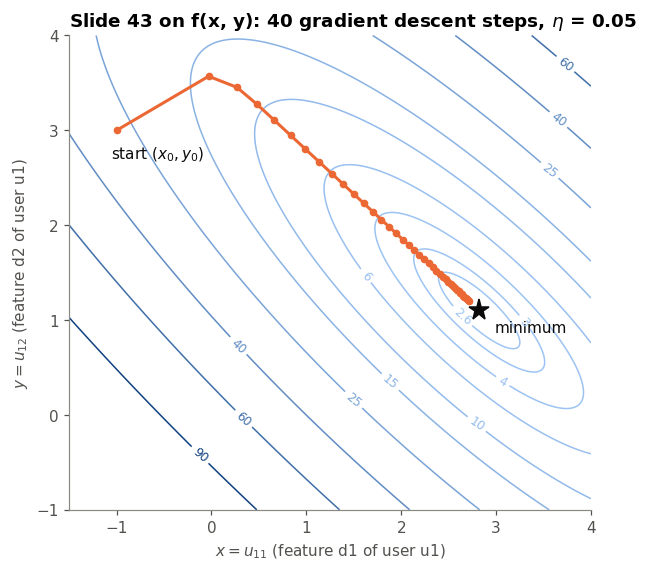

In [8]:
xs, ys = np.linspace(-1.5, 4.0, 300), np.linspace(-1.0, 4.0, 300)
X, Y = np.meshgrid(xs, ys)
Z = f_xy(X, Y)
blues = LinearSegmentedColormap.from_list("blues", ["#9ec5f4", "#104281"])

fig, ax = plt.subplots(figsize=(7, 5.6))
cs = ax.contour(X, Y, Z, levels=[2.6, 3, 4, 6, 10, 15, 25, 40, 60, 90], cmap=blues, linewidths=1)
ax.clabel(cs, fontsize=8, fmt="%g")
ax.plot(path[:, 0], path[:, 1], color=ORANGE, lw=2, marker="o", ms=4, zorder=3)
ax.plot(x_opt, y_opt, marker="*", ms=14, color=INK, zorder=4)
ax.annotate("start $(x_0, y_0)$", path[0], xytext=(-4, -18), textcoords="offset points", color=INK)
ax.annotate("minimum", (x_opt, y_opt), xytext=(10, -14), textcoords="offset points", color=INK)
ax.set_aspect("equal")
ax.grid(False)
ax.set_xlabel("$x = u_{11}$ (feature d1 of user u1)")
ax.set_ylabel("$y = u_{12}$ (feature d2 of user u1)")
ax.set_title("Slide 43 on f(x, y): 40 gradient descent steps, $\\eta$ = 0.05")
plt.show()

**Reading the picture.** The blue lines are contour lines: along each line $f$ has the same value, like the height lines on a map. Every orange segment is one step 3; the first ones are the steps of the table above. Things to notice:

- Every step starts at a right angle to the contour line it is on, because that is the direction in which $f$ goes down the fastest.
- The steps get shorter near the minimum, even though $\eta$ stays the same. The reason is that the slope (the gradient) gets smaller there.
- When only these two numbers can change, $f(x, y)$ is a bowl with one single lowest point, like the surface on slide 44. So gradient descent always ends there.
- The contour lines are long, stretched ovals: the bowl is much steeper in one direction than in the other. The steep direction limits how large $\eta$ may be (section 2.4), and the flat direction is why the last part of the path is slow.

##### 2.3.5.3 All numbers at once

**The subject.** The error function $f(U, V)$ of section 2.3.5 with all 20 unknowns changing together, using the update step of section 2.3.4 and starting from random values. The loop below is slide 43 with the point $(x_0, y_0)$ replaced by the pair $(U, V)$.

In [9]:
def mf_gradient_descent(R, K=2, eta=0.01, n_steps=2000, seed=42, U0=None, V0=None):
    # Matrix factorisation R ~ UV with the gradient descent algorithm of slide 43
    mask = ~np.isnan(R)
    R_filled = np.where(mask, R, 0.0)
    rng = np.random.default_rng(seed)

    # Step 1: arbitrary starting point, by default random values in [0, 1)
    U = rng.random((R.shape[0], K)) if U0 is None else U0.copy()
    V = rng.random((K, R.shape[1])) if V0 is None else V0.copy()

    history = []
    with np.errstate(over="ignore", invalid="ignore"):
        for step in range(n_steps):
            E = np.where(mask, R_filled - U @ V, 0.0)   # errors of the known ratings
            history.append(np.sum(E ** 2))      # f(U, V) at the current point
            if not np.isfinite(history[-1]):    # the steps were too large and f blew up
                break
            # Step 2: partial derivatives, both evaluated at the current (U, V)
            grad_U = -2 * E @ V.T
            grad_V = -2 * U.T @ E
            # Step 3: small step against the gradient (U and V both use the old values)
            U, V = U - eta * grad_U, V - eta * grad_V
            # Step 4: repeat
    return U, V, np.array(history)

U_gd, V_gd, hist = mf_gradient_descent(R, K=2, eta=0.01, n_steps=2000)
P_gd, P_slide = U_gd @ V_gd, U_slide @ V_slide

print(f"SSE: start {hist[0]:.2f}, end {sse(U_gd, V_gd):.3f} (RMSE {rmse(U_gd, V_gd):.3f})")
print("SSE at the start and after steps 1, 2, 3:", np.round(hist[:4], 2))
print(f"SSE below the slide 40 value ({sse(U_slide, V_slide):.2f}) from step {np.argmax(hist < sse(U_slide, V_slide))} on")
print("\nU =\n", U_gd)
print("\nV =\n", V_gd)
print("\nU*V =\n", P_gd)
print(f"\nPrediction for (u3, i2): {P_gd[2, 1]:.2f}   (slide 40: {P_slide[2, 1]:.2f})")
print(f"Prediction for (u5, i5): {P_gd[4, 4]:.2f}   (slide 40: {P_slide[4, 4]:.2f})")

SSE: start 201.24, end 2.541 (RMSE 0.332)
SSE at the start and after steps 1, 2, 3: [201.24 161.65 117.54  77.32]
SSE below the slide 40 value (24.89) from step 8 on

U =
 [[ 2.13  0.58]
 [ 1.69 -0.09]
 [ 0.38  1.81]
 [ 0.78  2.2 ]
 [ 1.69  1.65]]

V =
 [[2.02 0.49 1.44 2.04 0.79]
 [0.41 2.01 1.39 0.37 2.02]]

U*V =
 [[4.53 2.22 3.88 4.55 2.86]
 [3.39 0.66 2.32 3.42 1.15]
 [1.51 3.83 3.07 1.45 3.97]
 [2.48 4.81 4.19 2.41 5.07]
 [4.09 4.15 4.73 4.06 4.67]]

Prediction for (u3, i2): 3.83   (slide 40: 1.69)
Prediction for (u5, i5): 4.67   (slide 40: 1.95)


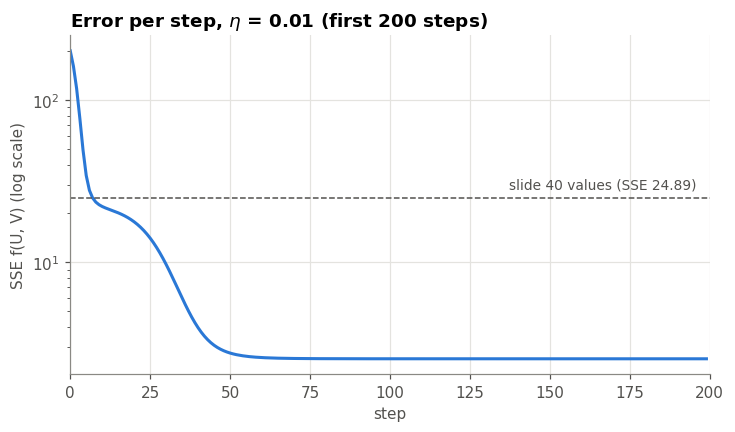

In [10]:
n_show = 200
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(np.arange(n_show), hist[:n_show], color=BLUE, lw=2)
ax.axhline(sse(U_slide, V_slide), color=MUTED, lw=1, ls="--")
ax.text(n_show * 0.98, sse(U_slide, V_slide) * 1.1, "slide 40 values (SSE 24.89)",
        ha="right", va="bottom", color=MUTED, fontsize=9)
ax.set_yscale("log")
ax.set_xlim(0, n_show)
ax.set_xlabel("step")
ax.set_ylabel("SSE f(U, V) (log scale)")
ax.set_title("Error per step, $\\eta$ = 0.01 (first 200 steps)")
plt.show()

**The first steps.** The first iterations of the outer loop, from the output above: the SSE is 201.24 at the random start, and 161.65, 117.54 and 77.32 after steps 1, 2 and 3.

**Result.** The SSE drops from about 201 to 2.54. The RMSE is about 0.33 ($\sqrt{2.54 / 23} = 0.33$), so a typical error is about a third of a star. After 8 steps the error is already lower than with the slide 40 matrices. After about 60 steps the curve is flat (the remaining 1800 steps are not shown): the gradient is almost zero, so step 3 hardly moves the point any more, and we have reached a minimum.

**The flat stretch.** The curve also slows down for a while at an SSE of about 20 to 23 (steps 8 to 25) before it drops again. That is close to the best error possible with only **one** feature (22.82, see section 2.5.2). In the first steps the two features behave almost like a single feature, and only later do they start to describe different things. Such flat stretches often happen when gradient descent passes near a saddle point: a flat spot that looks like a minimum in some directions but like a maximum in others, like the middle of a horse saddle.

**The missing ratings.** The two missing ratings are now predicted as about 3.83 for (u3, i2) and 4.67 for (u5, i5). Sections 2.5.3 and 2.5.5 explain why these are so different from the guesses on the slide.

### 2.4 Choosing the learning rate

The only setting of slide 43 is the step size $\eta$ ("make a **small** step"). If it is too small, the algorithm is slow; if it is too large, the algorithm fails. **Example:** on the slide 40 table, with $\eta = 0.01$ the error reaches its minimum in about 60 steps, with $\eta = 0.001$ it needs about 600 steps, and with $\eta = 0.05$ it never gets there.

**The subject.** The error function $f(U, V)$ of the slide 40 table (section 2.3.5), minimised as in section 2.3.5.3 with three values of $\eta$:

eta = 0.001  final SSE 2.54 after 2000 steps
eta = 0.01   final SSE 2.54 after 2000 steps
eta = 0.05   diverged after 872 steps


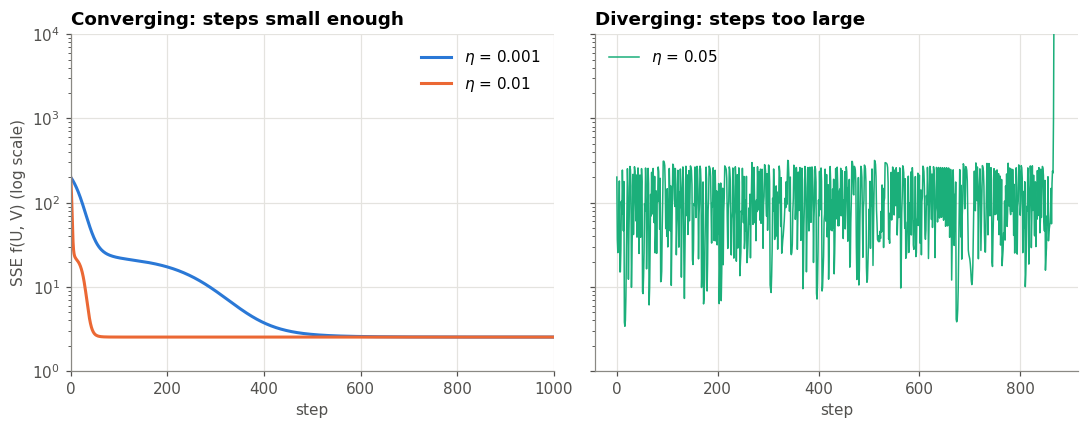

In [11]:
runs = [(0.001, BLUE), (0.01, ORANGE), (0.05, AQUA)]
fig, (ax_ok, ax_bad) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for eta, color in runs:
    _, _, h = mf_gradient_descent(R, eta=eta, n_steps=2000)
    finite = h[np.isfinite(h)]
    ax = ax_bad if eta == 0.05 else ax_ok
    ax.plot(np.arange(len(finite)), finite, color=color, lw=1 if eta == 0.05 else 2, label=f"$\\eta$ = {eta}")
    status = "diverged" if len(finite) < len(h) else f"final SSE {finite[-1]:.2f}"
    print(f"eta = {eta:<6} {status} after {len(finite)} steps")
ax_ok.set_xlim(0, 1000)
ax_ok.set_title("Converging: steps small enough")
ax_bad.set_title("Diverging: steps too large")
for ax in (ax_ok, ax_bad):
    ax.set_yscale("log")
    ax.set_ylim(1, 1e4)
    ax.set_xlabel("step")
    ax.legend(frameon=False)
ax_ok.set_ylabel("SSE f(U, V) (log scale)")
plt.tight_layout()
plt.show()

- **Too small** ($\eta = 0.001$): every step is safe, but it needs about ten times as many steps to get to the same error (about 600 instead of 60).
- **About right** ($\eta = 0.01$): reaches the minimum in about 60 steps.
- **Too large** ($\eta = 0.05$): the steps jump over the bottom of the valley. The error jumps up and down, and at some point it grows without limit (it "diverges"). In the picture of section 2.3.5.2: each step is so long that it lands higher up on the other side of the bowl.

A simple rule in practice: use the largest $\eta$ for which the error still goes down steadily. If the error goes up, halve $\eta$.

### 2.5 Remarks

#### 2.5.1 Introduction

Four things are worth knowing when gradient descent is used for matrix factorisation: the start must be random (section 2.5.2), there are many equally good answers (section 2.5.3), the error surface is not a simple bowl (section 2.5.4), and a small error on the known ratings is not the real goal (section 2.5.5).

**Example.** Four runs from different random starts all end with the same error 2.54, but with four different feature vectors for user u1 (section 2.5.3).

#### 2.5.2 Why the start must be random

If all features start with the same value, they stay equal forever, and the model behaves as if it had only one feature. **Example:** in section 2.3.5.1 both features of user u1 got the same update: $u_{11}$ and $u_{12}$ both went from 1 to 1.16.

This is no accident: if the two columns of $U$ are equal and the two rows of $V$ are equal, their updates are equal too, so the features stay copies of each other. That is why slide 47 says "initialize all variables at random" (the skeleton in **assignment.py** does the same with **np.random.rand**). The code runs 3000 steps from the all-ones start and compares the result with a model that has only one feature:

In [12]:
U_sym, V_sym, _ = mf_gradient_descent(R, eta=0.01, n_steps=3000, U0=np.ones((5, 2)), V0=np.ones((2, 5)))
U_k1, V_k1, _ = mf_gradient_descent(R, K=1, eta=0.01, n_steps=3000)
print("U after 3000 steps from all ones (both columns still equal):\n", U_sym)
print(f"\nSSE from the all-ones start, K = 2:  {sse(U_sym, V_sym):.3f}")
print(f"SSE with a single feature, K = 1:     {sse(U_k1, V_k1):.3f}")
print(f"SSE from a random start, K = 2:      {sse(U_gd, V_gd):.3f}")

U after 3000 steps from all ones (both columns still equal):
 [[1.38 1.38]
 [0.83 0.83]
 [0.96 0.96]
 [1.47 1.47]
 [1.68 1.68]]

SSE from the all-ones start, K = 2:  22.819
SSE with a single feature, K = 1:     22.819
SSE from a random start, K = 2:      2.541


#### 2.5.3 Many equally good answers

Different pairs $(U, V)$ can give exactly the same predictions, so there is not one single answer.

**The subject.** The matrices $U$ and $V$ of the model of section 1.2.1, and any $K \times K$ matrix $A$ that can be undone by another matrix $A^{-1}$ (its inverse). Then

$$(UA)(A^{-1}V) = UV .$$

So many different pairs $(U, V)$ are equally good, and different random starts end at different $U$ and $V$. This also means that a single feature value has no fixed meaning on its own. Names such as d1 and d2 on slide 40 are given afterwards, by looking at the result (compare slide 50).

##### -##-Example:-##-

**The subject.** The features of slide 40, with $A$ = "multiply by 2" and $A^{-1}$ = "multiply by 0.5", so every entry of $U$ is doubled and every entry of $V$ is halved. Then $u_1 = (2, 1.8)$ becomes $(4, 3.6)$ and $v_1 = (1.1, 0.8)$ becomes $(0.55, 0.4)$, and still $4 \cdot 0.55 + 3.6 \cdot 0.4 = 2.2 + 1.44 = 3.64$.

The code runs gradient descent from four different random starts:

In [13]:
for seed in [0, 1, 2, 3]:
    U_s, V_s, _ = mf_gradient_descent(R, eta=0.01, n_steps=3000, seed=seed)
    P = U_s @ V_s
    print(f"seed {seed}: SSE = {sse(U_s, V_s):.4f}, u1 = {U_s[0]}, "
          f"prediction (u3, i2) = {P[2, 1]:.2f}, (u5, i5) = {P[4, 4]:.2f}")

seed 0: SSE = 2.5406, u1 = [2.09 0.69], prediction (u3, i2) = 3.83, (u5, i5) = 4.67
seed 1: SSE = 2.5406, u1 = [0.94 2.08], prediction (u3, i2) = 3.83, (u5, i5) = 4.67
seed 2: SSE = 2.5406, u1 = [2.08 0.77], prediction (u3, i2) = 3.83, (u5, i5) = 4.67
seed 3: SSE = 2.5406, u1 = [0.78 2.01], prediction (u3, i2) = 3.83, (u5, i5) = 4.67


All four runs reach the same error and, in this small example, the same predictions, but user u1 gets a different feature vector each time.

#### 2.5.4 The error surface is not a simple bowl

The surface on slide 44 is a bowl with one lowest point. The error $f(U, V)$ is such a bowl only when one of $U$ and $V$ is kept fixed. **Example:** in section 2.3.5.2 only $u_{11}$ and $u_{12}$ could change, and the contour lines were ovals around one single lowest point.

When both $U$ and $V$ can change, this is no longer true. Because many pairs $(U, V)$ are equally good (section 2.5.3), $f$ has long valleys where the error is equally low. Gradient descent only promises to stop at a flat spot (where the gradient is zero), and which flat spot it reaches can depend on where it started. (Keeping one of $U$ and $V$ fixed, so that the problem becomes a simple bowl, solving that bowl exactly, and then switching roles, is the idea behind Alternating Least Squares on slide 49.)

#### 2.5.5 Overfitting

A model that follows the known ratings too closely also learns their random noise, and then tends to give extreme values for items it has not seen. This is called **overfitting**. **Example:** gradient descent fits the known ratings of slide 40 much better than the slide's own values (SSE 2.54 against 24.89), but that alone does not mean that its guesses for the missing ratings (3.83 and 4.67) are better than the slide's (1.69 and 1.95).

The rating table has 23 known ratings, and the model has 20 unknowns. With almost as many unknowns as ratings, gradient descent can fit the known ratings almost perfectly. But what we actually care about are the predictions for the **missing** ratings. Slide 48 fights overfitting with regularisation (section 2.6.3).

### 2.6 Variants used in practice (slides 47 and 48)

#### 2.6.1 Introduction

Two changes to plain gradient descent are common: SGD (Stochastic Gradient Descent), which takes a small step after every single rating instead of after all of them (section 2.6.2), and regularisation, which adds a penalty on large numbers against overfitting (section 2.6.3). The penalty uses the squared length $\lVert u \rVert^2$ of the feature vectors and a strength $\lambda$.

**Example.** On the 2 x 3 table of section 2.3.3, the first SGD step moves $u_1$ from 1 to 1.2; with a small penalty it moves to 1.199 instead (both worked out below).

#### 2.6.2 Stochastic gradient descent (slide 47)

The version used so far, called batch gradient descent, computes the derivatives from **all** known ratings before it takes a single step. SGD takes a small step after **every single rating** instead, which is much faster for big data such as the 100 million Netflix ratings. The ratings are visited in random order, and "stochastic" simply means "random". **Example:** with the 4 known ratings of the 2 x 3 table, one pass of SGD over the data makes 4 small steps, where batch gradient descent makes a single step.

**The subject.** The squared error of a single known rating $(i, j)$,

$$e_{ij}^2 = \left(r_{ij} - u_i^\top v_j\right)^2 .$$

Its derivative is $-2\, e_{ij}\, v_j$ with respect to $u_i$ and $-2\, e_{ij}\, u_i$ with respect to $v_j$. Taking the step of slide 43 with these derivatives, and leaving out the factor 2 as mentioned in section 2.3.4, gives

$$u_i \leftarrow u_i + \eta\, e_{ij}\, v_j, \qquad v_j \leftarrow v_j + \eta\, e_{ij}\, u_i,$$

which is exactly the update on slides 46 and 47. As before, the update of $v_j$ uses the old $u_i$.

##### -##-Example:-##-

**The subject.** The 2 x 3 table of section 2.3.3 ($K = 1$) with the squared errors of its four known ratings, $(5 - u_1 v_1)^2$, $(3 - u_1 v_2)^2$, $(4 - u_2 v_1)^2$ and $(2 - u_2 v_3)^2$ (their sum is $f(u, v)$), the start $u = (1, 1)$, $v = (1, 1, 1)$ (where $f = 30$), and $\eta = 0.05$. The ratings are visited in the order (1, 1), (1, 2), (2, 1), (2, 3). SGD has two nested loops: the inner loop over the ratings and the outer loop over the passes.

**Inner loop: the four ratings of pass 1.**

| rating $(i, j)$ | $r_{ij}$ | prediction | error $e_{ij}$ | new $u_i$ | new $v_j$ |
|---|---|---|---|---|---|
| (1, 1) | 5 | $1 \cdot 1 = 1$ | 4 | $u_1 = 1 + 0.05 \cdot 4 \cdot 1 = 1.2$ | $v_1 = 1 + 0.05 \cdot 4 \cdot 1 = 1.2$ |
| (1, 2) | 3 | $1.2 \cdot 1 = 1.2$ | 1.8 | $u_1 = 1.2 + 0.05 \cdot 1.8 \cdot 1 = 1.29$ | $v_2 = 1 + 0.05 \cdot 1.8 \cdot 1.2 = 1.108$ |
| (2, 1) | 4 | $1 \cdot 1.2 = 1.2$ | 2.8 | $u_2 = 1 + 0.05 \cdot 2.8 \cdot 1.2 = 1.168$ | $v_1 = 1.2 + 0.05 \cdot 2.8 \cdot 1 = 1.34$ |
| (2, 3) | 2 | $1.168 \cdot 1 = 1.168$ | 0.832 | $u_2 = 1.168 + 0.05 \cdot 0.832 \cdot 1 = 1.2096$ | $v_3 = 1 + 0.05 \cdot 0.832 \cdot 1.168 = 1.0486$ |

**Outer loop: the passes.** After pass 1, $f = 19.36$; after pass 2, $f = 9.59$; after pass 3, $f = 3.40$. ($f$ goes down more slowly here than with the batch steps of section 2.3.4, partly because the factor 2 was left out, which makes every step half as long.)

In [14]:
# Stochastic gradient descent on the 2 x 3 example table (K = 1)
ratings_toy = [(0, 0), (0, 1), (1, 0), (1, 2)]   # the known ratings (i, j), counted from 0, in visiting order

def sgd_toy(lam, n_passes=3):
    u, v = np.ones(2), np.ones(3)
    for p in range(1, n_passes + 1):              # outer loop: passes over all ratings
        for i, j in ratings_toy:                  # inner loop: one rating at a time
            e = R_toy[i, j] - u[i] * v[j]
            u_old = u[i]                          # the update of v_j uses the old u_i
            u[i] = u[i] + eta_toy * (e * v[j] - lam * u[i])
            v[j] = v[j] + eta_toy * (e * u_old - lam * v[j])
            if p == 1:
                print(f"  pass 1, rating ({i + 1},{j + 1}): e = {e:.4f}, u_{i + 1} = {u[i]:.4f}, v_{j + 1} = {v[j]:.4f}")
        f_val = f_toy(u, v)
        f_lam = f_val + lam * (np.sum(u ** 2) + np.sum(v ** 2))
        print(f"after pass {p}: f = {f_val:.4f}, f_lambda = {f_lam:.4f}")

sgd_toy(lam=0.0)

  pass 1, rating (1,1): e = 4.0000, u_1 = 1.2000, v_1 = 1.2000
  pass 1, rating (1,2): e = 1.8000, u_1 = 1.2900, v_2 = 1.1080
  pass 1, rating (2,1): e = 2.8000, u_2 = 1.1680, v_1 = 1.3400
  pass 1, rating (2,3): e = 0.8320, u_2 = 1.2096, v_3 = 1.0486
after pass 1: f = 19.3647, f_lambda = 19.3647
after pass 2: f = 9.5908, f_lambda = 9.5908
after pass 3: f = 3.3985, f_lambda = 3.3985


#### 2.6.3 Regularisation (slide 48)

To stop the numbers in $U$ and $V$ from becoming too large, a penalty for large values is added to the error function. As a result, every step pulls every number a little towards 0, so a value only becomes large if the ratings really call for it. **Example:** on the 2 x 3 table, the first SGD step moves $u_1$ to 1.199 instead of 1.2 (worked out below).

**The subject.** The error function $f(U, V)$ of section 1.2.2, together with the squared length of a feature vector, $\lVert u_i \rVert^2 = \sum_{d=1}^{K} u_{id}^2$, and the regularisation strength $\lambda \ge 0$ (the Greek letter lambda), which says how strongly large values are punished. The default in **assignment.py** is $\lambda = 0.02$.

**The error function with penalty.** We call the new error function $f_\lambda$:

$$f_\lambda(U, V) = \sum_{(i,j)\in\Omega} \left(r_{ij} - u_i^\top v_j\right)^2 + \lambda \left(\sum_{i=1}^{m} \lVert u_i \rVert^2 + \sum_{j=1}^{n} \lVert v_j \rVert^2\right).$$

**The derivatives and the update.** The penalty adds $2\lambda u_{id}$ to $\partial f / \partial u_{id}$ and $2\lambda v_{dj}$ to $\partial f / \partial v_{dj}$. For all entries at once this gives

$$\nabla_U f_\lambda = -2\, E V^\top + 2\lambda U, \qquad \nabla_V f_\lambda = -2\, U^\top E + 2\lambda V .$$

The SGD update per rating of section 2.6.2 (again without the factor 2) becomes

$$u_i \leftarrow u_i + \eta\,\left(e_{ij}\, v_j - \lambda\, u_i\right), \qquad v_j \leftarrow v_j + \eta\,\left(e_{ij}\, u_i - \lambda\, v_j\right).$$

**Comparing with slide 48.** Two details:

- The second line of slide 48 has $\lambda \cdot u_{item}$. Working out the derivative gives the item vector $v_j$ there, not a user vector.
- As in section 2.3.4, both updates should use the values from **before** the step, so the update of $v_j$ uses the old $u_i$.

These are the formulas behind the **regularization** parameter of **matrix_factorization** in **assignment.py**.

##### -##-Example:-##-

**The subject.** The 2 x 3 table of section 2.3.3 with the error function with penalty

$$f_\lambda(u, v) = f(u, v) + \lambda \left(u_1^2 + u_2^2 + v_1^2 + v_2^2 + v_3^2\right),$$

where $f(u, v)$ is the error function of section 2.3.3, with $\lambda = 0.02$ and the SGD passes of section 2.6.2 ($\eta = 0.05$, same start and order).

- **Penalty of one vector.** On slide 40, $\lVert u_1 \rVert^2 = \lVert (2, 1.8) \rVert^2 = 4 + 3.24 = 7.24$, so with $\lambda = 0.02$ this vector adds $0.02 \cdot 7.24 = 0.14$ to $f_\lambda$.

**Inner loop: the four ratings of pass 1.**

| rating $(i, j)$ | error $e_{ij}$ | new $u_i$ | new $v_j$ |
|---|---|---|---|
| (1, 1) | 4 | $u_1 = 1 + 0.05 \cdot (4 \cdot 1 - 0.02 \cdot 1) = 1.199$ | $v_1 = 1 + 0.05 \cdot (4 \cdot 1 - 0.02 \cdot 1) = 1.199$ |
| (1, 2) | 1.8010 | $u_1 = 1.2879$ | $v_2 = 1.1070$ |
| (2, 1) | 2.8010 | $u_2 = 1.1669$ | $v_1 = 1.3379$ |
| (2, 3) | 0.8331 | $u_2 = 1.2074$ | $v_3 = 1.0476$ |

Every new value is a little smaller than without the penalty (for example 1.199 instead of 1.2).

**Outer loop: the passes.** After passes 1, 2 and 3, $f_\lambda = 19.59$, $9.93$ and $3.79$, of which the penalty is only a small part ($f$ alone is 19.44, 9.74 and 3.54).

In [15]:
# The same passes with regularisation strength lambda = 0.02
sgd_toy(lam=0.02)

  pass 1, rating (1,1): e = 4.0000, u_1 = 1.1990, v_1 = 1.1990
  pass 1, rating (1,2): e = 1.8010, u_1 = 1.2879, v_2 = 1.1070
  pass 1, rating (2,1): e = 2.8010, u_2 = 1.1669, v_1 = 1.3379
  pass 1, rating (2,3): e = 0.8331, u_2 = 1.2074, v_3 = 1.0476
after pass 1: f = 19.4448, f_lambda = 19.5894
after pass 2: f = 9.7356, f_lambda = 9.9333
after pass 3: f = 3.5371, f_lambda = 3.7853


---

## 3. Summary

- Matrix factorisation (section 1) turns "predict the missing ratings" into "find $U$ and $V$ that make the squared error $f(U, V) = \sum_{(i,j)\in\Omega} (r_{ij} - u_i^\top v_j)^2$ on the known ratings as small as possible".
- Gradient descent (section 2.2) is used unchanged. The point $(x, y)$ is simply replaced by all entries of $U$ and $V$ (section 2.3.2).
- The partial derivatives (section 2.3.3) are $\partial f / \partial u_{id} = -2 \sum_j e_{ij} v_{dj}$ and $\partial f / \partial v_{dj} = -2 \sum_i e_{ij} u_{id}$, or for all entries at once $\nabla_U f = -2 E V^\top$ and $\nabla_V f = -2 U^\top E$ (section 2.3.4). From the all-ones start of slide 40: $\partial f / \partial u_{11} = -16$ and $\partial f / \partial v_{11} = -12$.
- One step: compute the errors of the known ratings, compute both derivative tables at the current point, move $U$ and $V$ a step of size $\eta$ against them, and repeat.
- In practice: start at random values (section 2.5.2), pick $\eta$ small enough that the error does not blow up (section 2.4), and use regularisation against overfitting (sections 2.5.5 and 2.6.3). SGD (section 2.6.2) takes a step after every single rating.

---